# PPThinning\n\nSimulating point processes by thinning.\n\nPython port of the MATLAB `PPThinning` helpfile (`helpfiles/PPThinning.m`).

## Simulate PP via thinning

Given a conditional intensity function, we generate a point process consistent with this CIF.

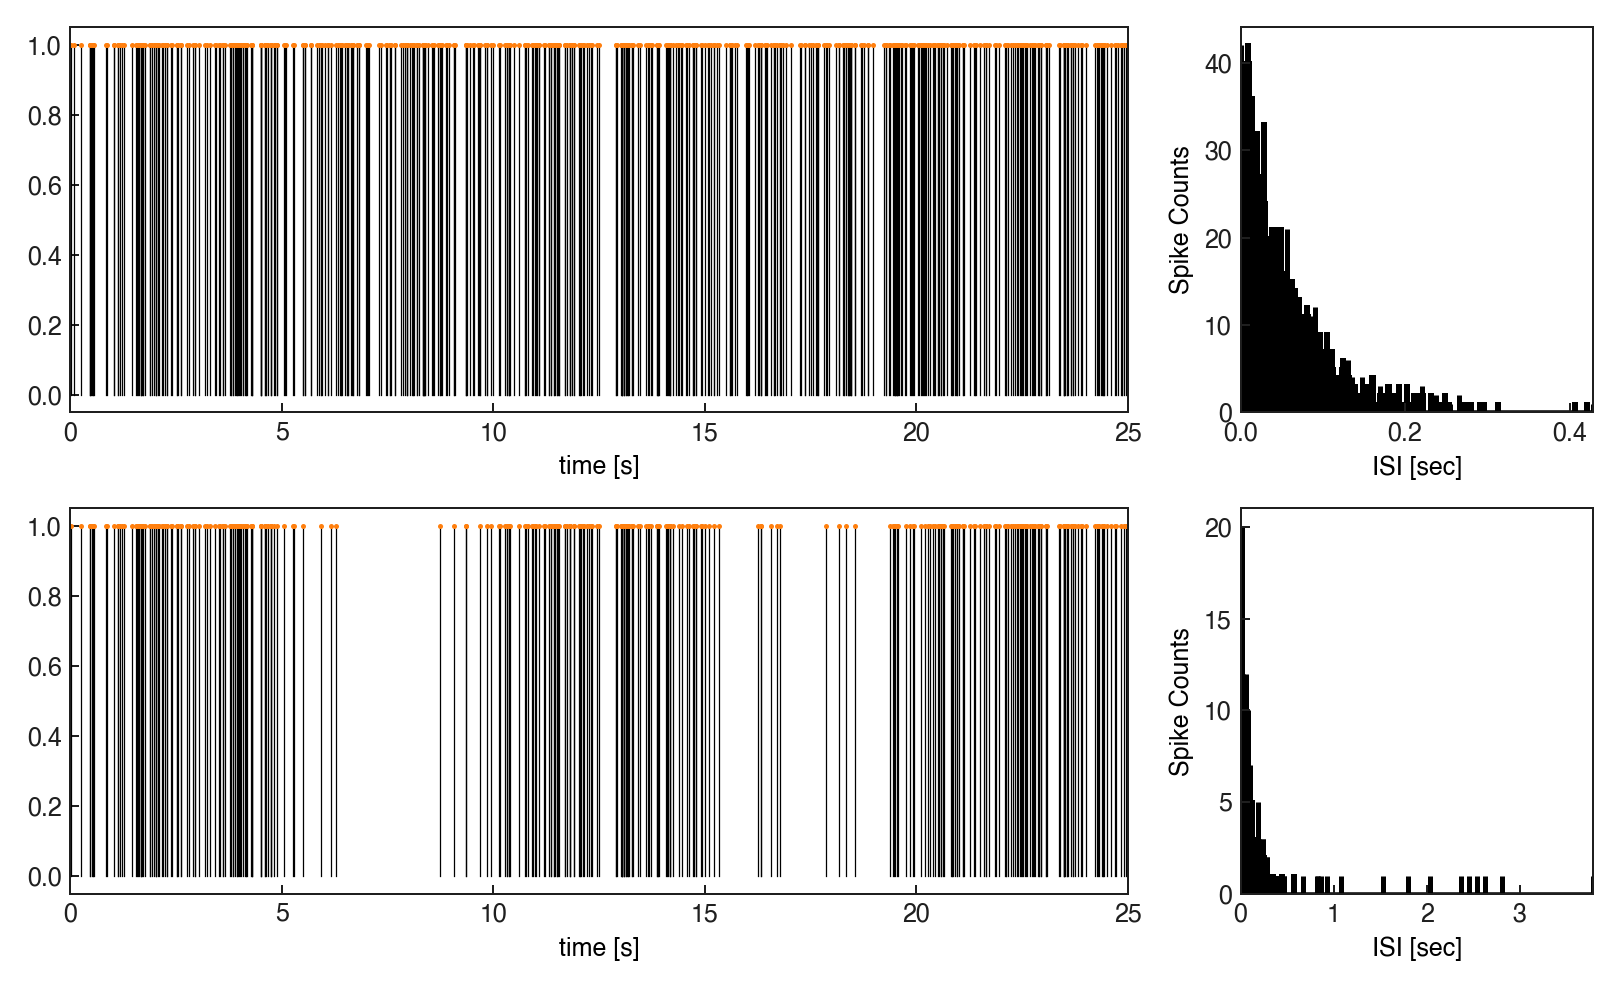

In [ ]:
# SECTION 1: Simulate PP via thinning
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import Covariate, nspikeTrain, nstColl, CIF
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="PPThinning", output_root=OUTPUT_ROOT, expected_count=4)
def capture(label, fn):
    fig = __tracker.new_figure(label); plt.close(fig); fn(); __tracker._active_fig = plt.gcf()


## Basic Example

In [ ]:
# SECTION 2: Basic Example
delta = 0.001; Tmax = 100; time = np.arange(0, Tmax + delta, delta); f = 0.1
lambdaData = 10*np.sin(2*np.pi*f*time) + 10
lam = Covariate(time, lambdaData, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
lambdaBound = float(np.max(lambdaData))
rng = np.random.default_rng(0)
N = int(lambdaBound * 1.5 * Tmax)
u = rng.random(N); w = -np.log(u) / lambdaBound
tSpikes = np.cumsum(w); tSpikes = tSpikes[tSpikes <= Tmax]
ratio = np.asarray(lam.getValueAt(tSpikes)).flatten() / lambdaBound
u2 = rng.random(len(ratio)); tThin = tSpikes[ratio >= u2]

## Compare Constant rate process vs. thinned process

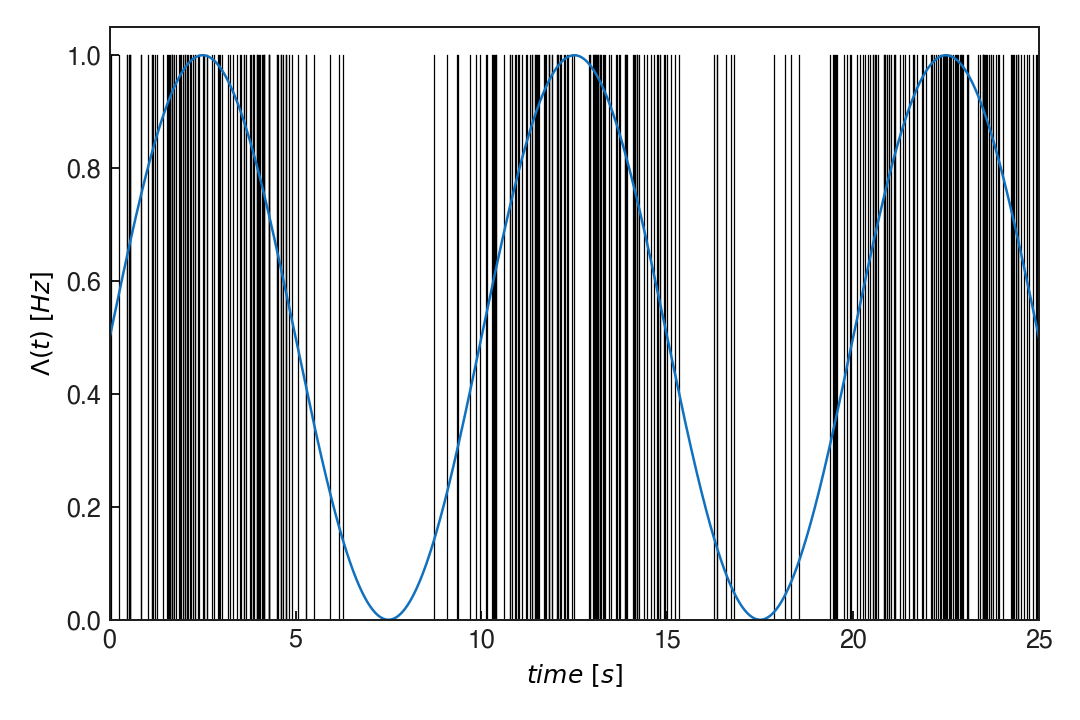

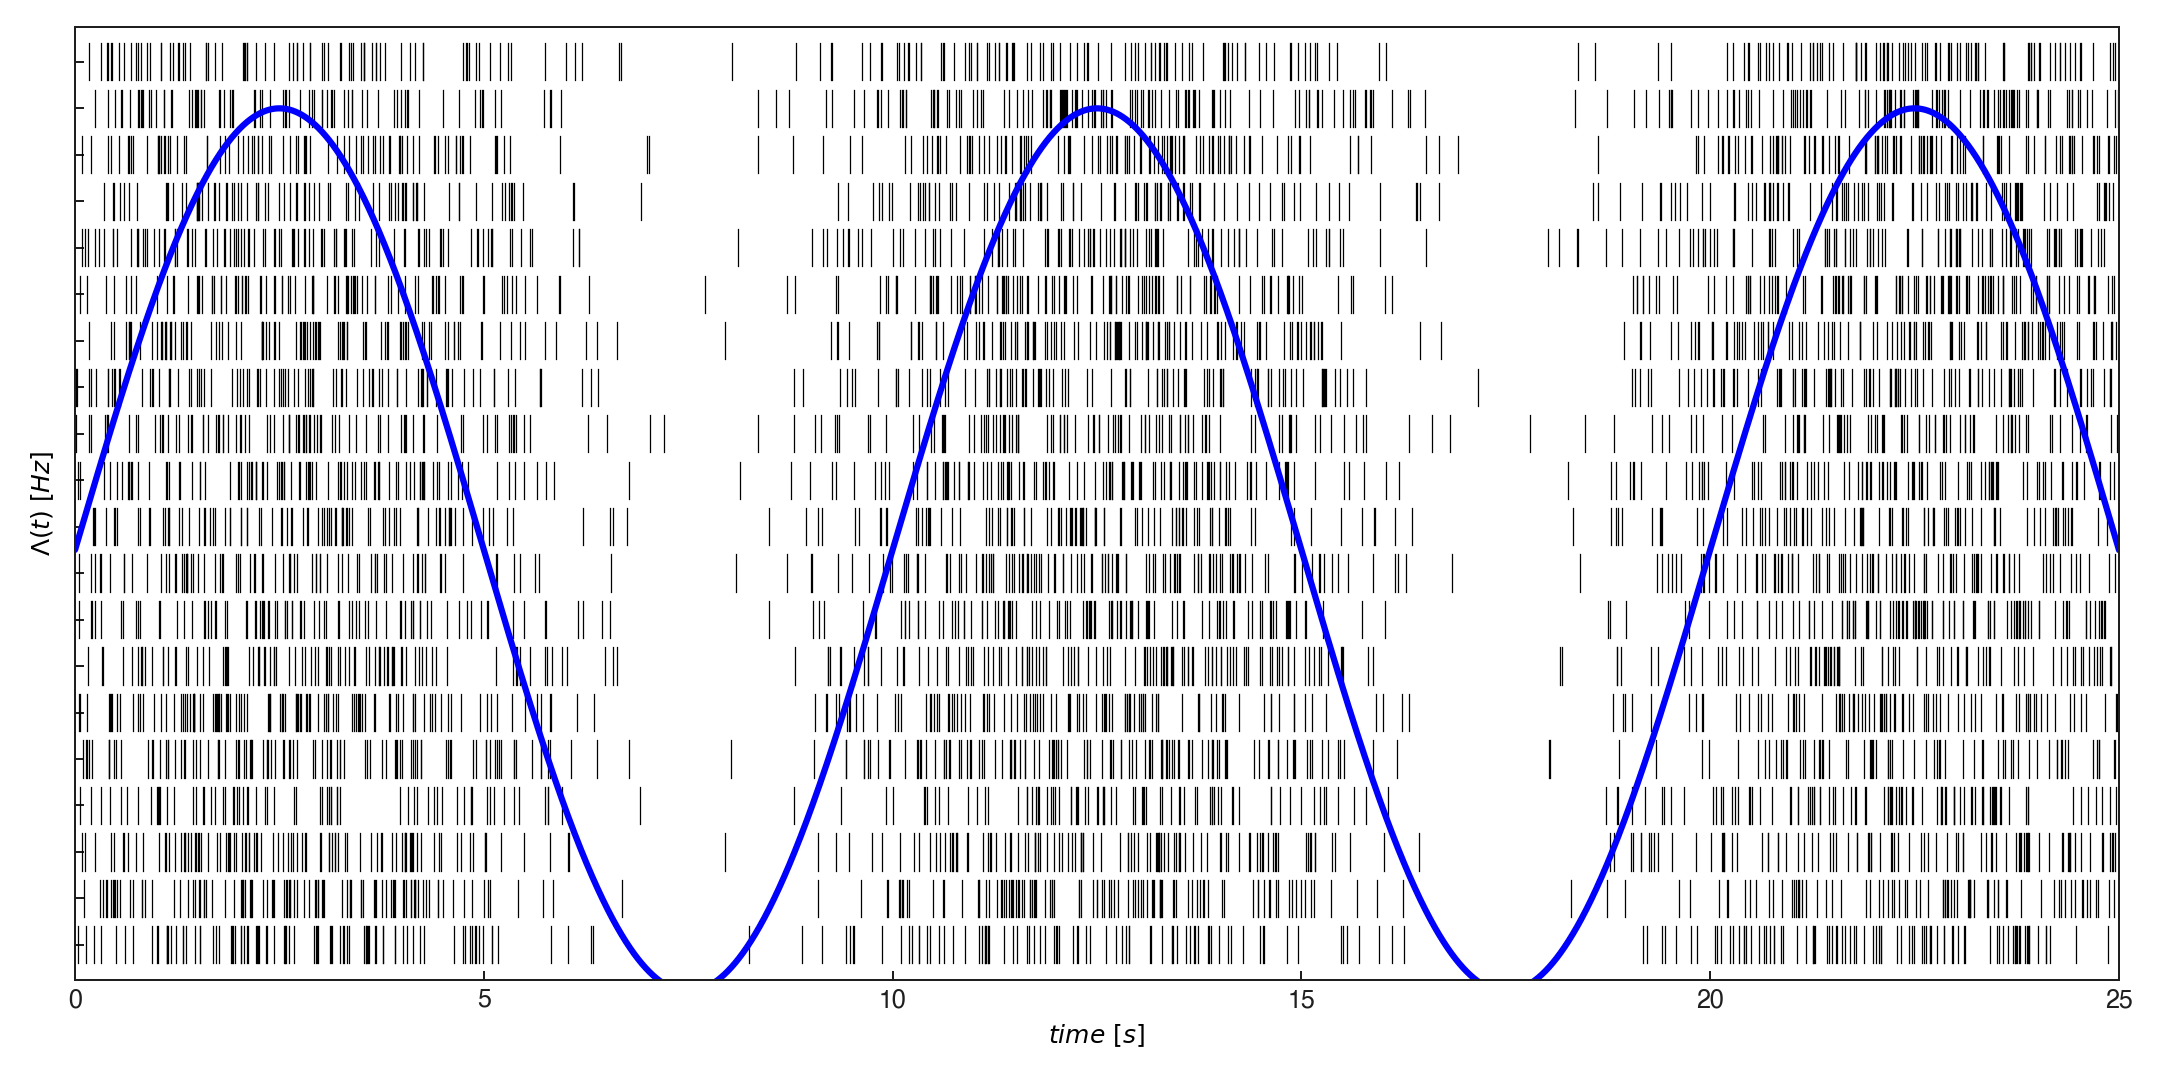

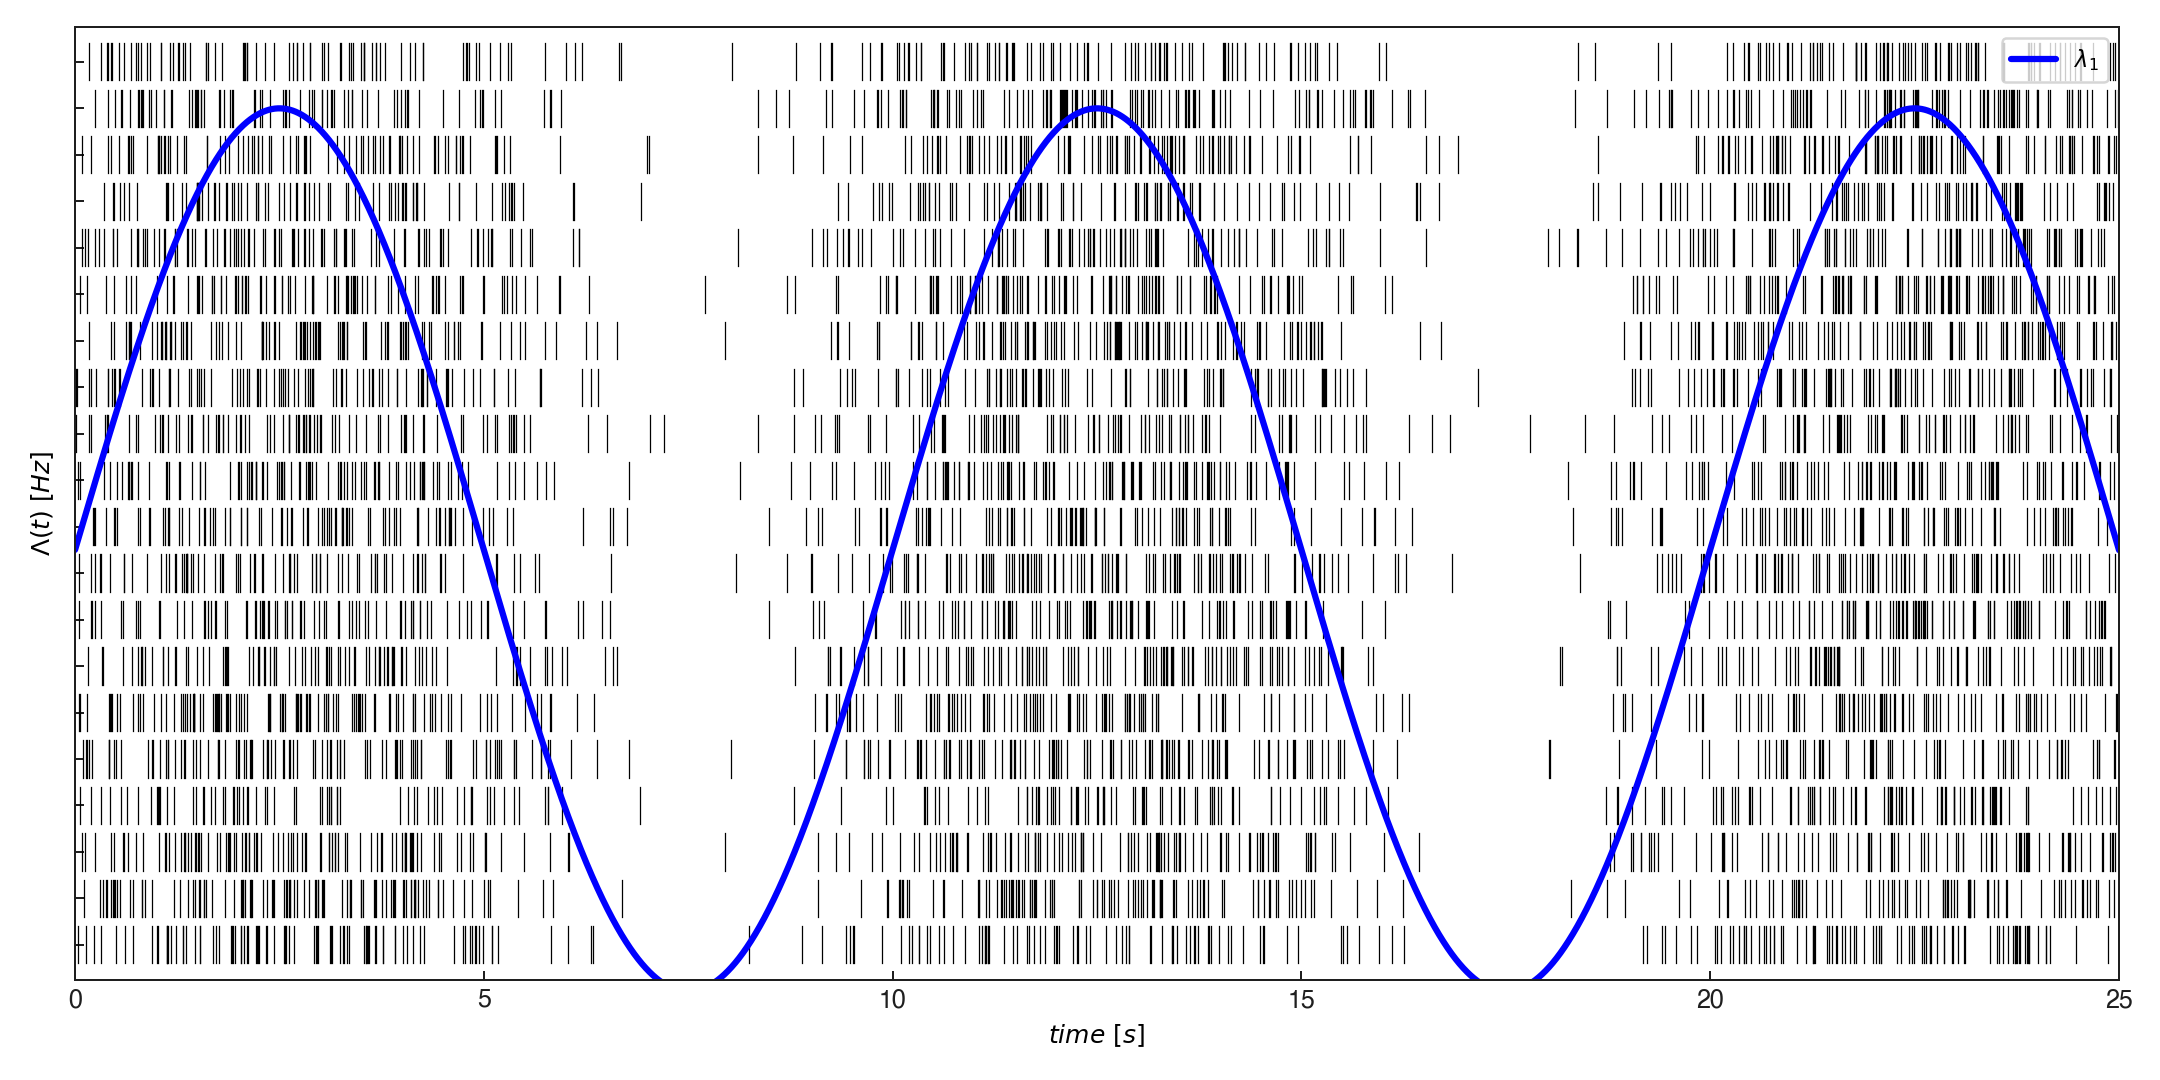

In [ ]:
# SECTION 3: Compare Constant rate process vs. thinned process
# Match MATLAB §3: n1 = nspikeTrain(tSpikes); n2 = nspikeTrain(tSpikesThin)
# happen inside this section, not the Basic Example section.
n1 = nspikeTrain(tSpikes); n2 = nspikeTrain(tThin)

def _start_fig(label, figsize=(8.0, 4.5)):
    # Open a tracker slot, then discard the placeholder axes/title cleanly so
    # nothing from the placeholder leaks into the saved PNG.
    fig = __tracker.new_figure(label)
    fig.clf()
    fig.set_size_inches(*figsize)
    __tracker._active_fig = fig
    __tracker._active_ax = None
    return fig

# Figure 1: 2 rows x 2 cols with width_ratios=[3,1] — raster wide, ISI hist narrow.
# Matches MATLAB layout where each row pairs a tall wide raster with a tight
# ISI histogram on the right. MATLAB calls n.plotISIHistogram directly, which
# uses the nSTAT default 1 ms bin width — mirror that here by delegating to
# nspikeTrain.plotISIHistogram(handle=ax) instead of inline plt.hist.
fig1 = _start_fig("constant-rate vs thinned process", figsize=(9.0, 5.5))
gs = fig1.add_gridspec(2, 2, width_ratios=[3, 1])
# Match MATLAB: each ISI histogram autoscales to ITS OWN data range, so the
# constant-rate n1 panel (max ISI ~0.4 s) and the thinned n2 panel
# (max ISI ~3.5 s) both occupy the full panel width. Sharing a common
# x-limit (the union max) crushed the top-right n1 histogram into the
# leftmost ~10% of its panel and made it read as blank.
_isi1 = n1.getISIs(); _isi2 = n2.getISIs()
isi_xmax_n1 = float(np.max(_isi1)) if _isi1.size else 0.0
isi_xmax_n2 = float(np.max(_isi2)) if _isi2.size else 0.0
# subplot(2,2,1): n1.plot; plot(tSpikes,ones(size(tSpikes)),'.'); v=axis; axis([0 Tmax/4 v(3) v(4)])
ax = fig1.add_subplot(gs[0, 0]); n1.plot(currentHandle=ax)
ax.plot(tSpikes, np.ones_like(tSpikes), '.', color='tab:orange', markersize=2)
ax.set_xlim(0, Tmax/4); ax.set_xlabel('time [s]')
# subplot(2,2,2): n1.plotISIHistogram — MATLAB renders ISI bars filled
# solid black; nspikeTrain.plotISIHistogram defaults to a light tan
# color.  Recolor the resulting Rectangle patches to black so the
# panel reads as MATLAB's filled-bar histogram (Reviewer iter-46 polish).
ax = fig1.add_subplot(gs[0, 1])
n1.plotISIHistogram(handle=ax)
from matplotlib.patches import Rectangle as _Rectangle
for _patch in ax.patches:
    if isinstance(_patch, _Rectangle):
        _patch.set_facecolor('k')
        _patch.set_edgecolor('k')
if isi_xmax_n1 > 0:
    ax.set_xlim(0, isi_xmax_n1)
# subplot(2,2,3): n2.plot; plot(tSpikes,ones(size(tSpikes)),'.'); v=axis; axis([0 Tmax/4 v(3) v(4)])
ax = fig1.add_subplot(gs[1, 0]); n2.plot(currentHandle=ax)
ax.plot(tThin, np.ones_like(tThin), '.', color='tab:orange', markersize=2)
ax.set_xlim(0, Tmax/4); ax.set_xlabel('time [s]')
# subplot(2,2,4): n2.plotISIHistogram — same filled-black recolor as n1.
ax = fig1.add_subplot(gs[1, 1])
n2.plotISIHistogram(handle=ax)
for _patch in ax.patches:
    if isinstance(_patch, _Rectangle):
        _patch.set_facecolor('k')
        _patch.set_edgecolor('k')
if isi_xmax_n2 > 0:
    ax.set_xlim(0, isi_xmax_n2)
fig1.tight_layout()

# Figure 2: thinned spikes + scaled rate p(t) — single panel matching MATLAB's
# squarish portrait aspect. MATLAB renders the raster via n2.plot and the
# scaled rate via a Covariate (scaledProb = lambda * (1/lambdaBound)) .plot —
# mirror that here by delegating to the nspikeTrain / Covariate plotting paths
# instead of inline vlines + plt.plot.
fig2 = _start_fig("thinned spikes + scaled rate", figsize=(6.0, 4.0))
ax2 = fig2.add_subplot(1,1,1)
n2.plot(currentHandle=ax2)
scaledProb = Covariate(time, lambdaData / lambdaBound, "Lambda(t)", "time", "s", "Hz", ["lambda_1"])
scaledProb.plot(handle=ax2)
ax2.set_xlim(0, Tmax/4); ax2.set_ylim(0, 1.05)
ax2.set_xlabel(r'$time\ [s]$')
# MATLAB labels this panel ``\Lambda(t) [Hz]`` even though the data
# is normalized to [0, 1] by scaledProb = lambda*(1/lambdaBound).
# Match MATLAB literally (Reviewer iter-46 polish).
ax2.set_ylabel(r'$\Lambda(t)\ [Hz]$')
# Match MATLAB's integer-second x-ticks (0, 5, 10, 15, 20, 25).
from matplotlib.ticker import MultipleLocator as _MultipleLocator, FormatStrFormatter as _FormatStrFormatter
ax2.xaxis.set_major_locator(_MultipleLocator(5))
ax2.xaxis.set_major_formatter(_FormatStrFormatter('%d'))
# MATLAB does not render a legend on this panel — suppress the empty/auto
# legend the Covariate.plot path adds so the figure matches MATLAB exactly.
_leg = ax2.get_legend()
if _leg is not None:
    _leg.remove()
fig2.tight_layout()

## Simulate multiple realizations of a point process via thinning

The CIF class can generated realizations of a point process given a conditional intensity function (defined as a Covariate or SignalObj)

In [ ]:
# SECTION 4: Simulate multiple realizations of a point process via thinning
spikeColl = CIF.simulateCIFByThinningFromLambda(lam, 20, seed=1)

# MATLAB lines(1) default blue and a clean ROUND-cap line — Approach C from
# the PPThinning parity investigation (Builder iter-52A).  Pure '#0000ee' had
# slightly off hue vs MATLAB; the lines(1) RGB triple is closer.
# MATLAB's MLX rendering uses pure (0,0,1) blue — sampled the published
# PPThinning_04.png with PIL and the dominant blue pixel was ~(10,10,243).
# Approach C iter-2: use pure blue, not the lines(1) cyan-blue, to match.
_MATLAB_BLUE = (0.0, 0.0, 1.0)


def _draw_lambda_overlay(ax, time, lambdaData, n_rows):
    """MATLAB renders lambda as a saturated blue line drawn THROUGH the raster
    on a shared axis.  Scale lambda onto the raster's row span so the sine
    threads through the dense spike band (rather than compressing into the
    baseline), match MATLAB's lines(1) blue, and explicitly request round
    cap/join for the smoothest Bezier-like rendering matplotlib's agg backend
    offers."""
    _lam_min = float(np.min(lambdaData))
    _lam_max = float(np.max(lambdaData))
    _lam_scaled = (lambdaData - _lam_min) / max(_lam_max - _lam_min, 1e-12) * (n_rows - 1)
    ax.plot(
        time, _lam_scaled,
        color=_MATLAB_BLUE,
        linewidth=2.5,
        solid_capstyle="round",
        solid_joinstyle="round",
        antialiased=True,
        label=r"$\lambda_1$",
    )


def _match_matlab_raster_axes(ax, Tmax):
    """Strip the matplotlib-only ``Spike Train Raster`` title that
    ``nstColl.plot`` adds (MATLAB has no panel title) and hide the numeric
    y-tick labels (MATLAB's helpfile renders a placeholder ``1`` per row,
    visually a blank column — the cleanest match is no labels at all so the
    raster body is what the eye reads)."""
    ax.set_title("")
    ax.set_yticklabels([])
    ax.set_xlim(0, Tmax / 4)
    ax.set_xlabel(r"$time\ [s]$")
    ax.set_ylabel(r"$\Lambda(t)\ [Hz]$")


# Figure 3: ensemble raster WITH sine overlay — MATLAB PPThinning_03.png is
# captured in the .mlx after lambda.plot has already been overlaid on the
# same axis handle (MATLAB holds the figure), so the published PNG shows the
# sine.  Mirror that (Builder iter-52A, MATLAB parity rule binding).
fig3 = _start_fig("20 thinning realizations + rate", figsize=(12.0, 6.0))
ax3 = fig3.add_subplot(1, 1, 1)
spikeColl.plot(handle=ax3)
n_rows = spikeColl.numSpikeTrains
_draw_lambda_overlay(ax3, time, lambdaData, n_rows)
_match_matlab_raster_axes(ax3, Tmax)

# Figure 4: ensemble raster + lambda(t) overlay (same as figure 3 in the
# MATLAB .mlx — both snapshots are taken after the overlay is drawn).  Kept
# as a separate Python figure for the figure-tracker's per-snapshot contract.
fig3b = _start_fig("20 thinning realizations + rate", figsize=(12.0, 6.0))
ax3b = fig3b.add_subplot(1, 1, 1)
spikeColl.plot(handle=ax3b)
_draw_lambda_overlay(ax3b, time, lambdaData, n_rows)
_match_matlab_raster_axes(ax3b, Tmax)
ax3b.legend(loc="upper right", frameon=True, fontsize=9)

__tracker.finalize()
